# First calls of the changepoint detector 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

# our package
from AMOC_Detector import Detector, gaussian_mean_change, rbf_kernel, kfdr

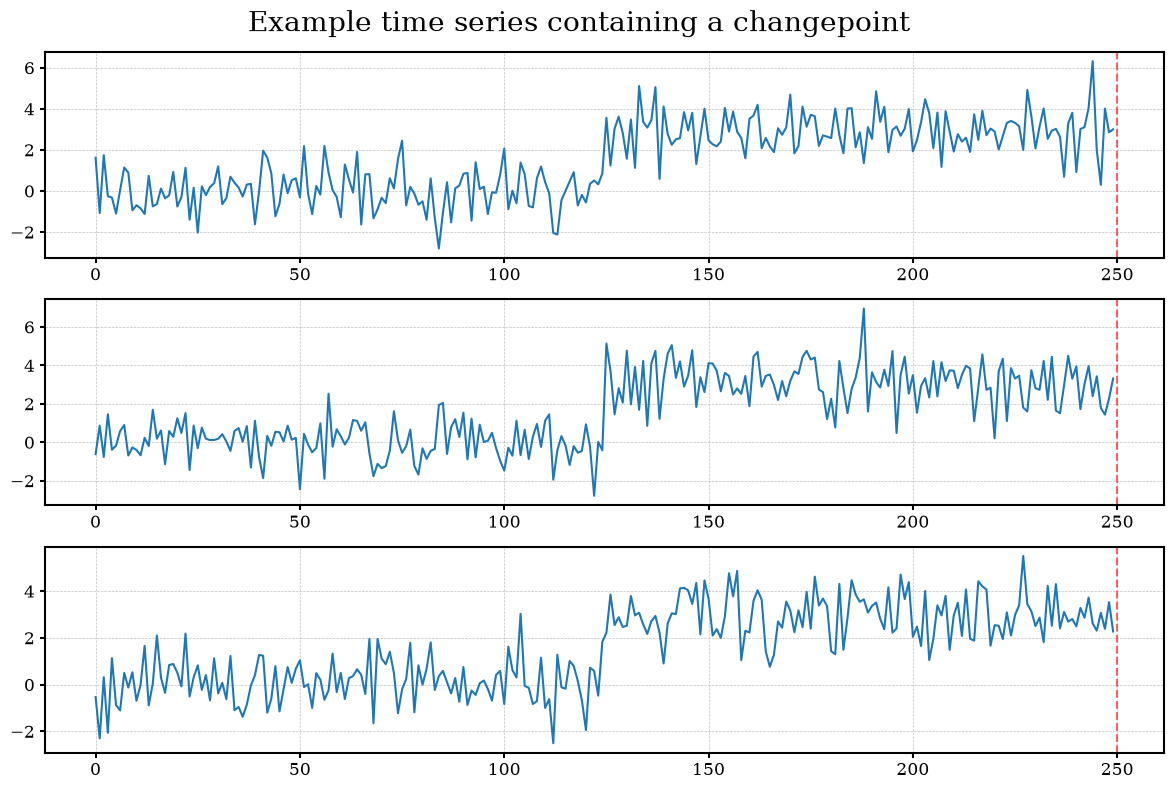

In [2]:
# creating an instance of our detector for each case 
parametric_detector = Detector(cost_function=gaussian_mean_change, penalty=10)
kernel_detector = Detector(cost_function=kfdr, penalty=10)

# generating some example series 
np.random.seed(1)

ts = np.random.multivariate_normal(mean = np.array([0,0,0]), cov = np.eye(3), size = 250)
ts[125:, :] += 3

# showing our series 
fig, axes = plt.subplots(3, figsize = (12,8))

axes[0].plot(ts[:, 0])
axes[1].plot(ts[:, 1])
axes[2].plot(ts[:, 2])

axes = axes.flatten()

for ax in axes:
    ax.axvline(x = 250, color = 'red', linestyle = '--', alpha = 0.6)

fig.suptitle('Example time series containing a changepoint', fontsize = 20)
plt.tight_layout()


## can our methods detect this? 

In [3]:
parametric_detector.detect(time_series = ts)

(array([125]),)

In [4]:
kernel_detector.detect(time_series = ts)

  0%|          | 0/230 [00:00<?, ?it/s]

100%|██████████| 230/230 [01:01<00:00,  3.76it/s]


(array([125]),)

## How should you tune $\beta$?

We discussed this in the meeting, but I think an example could help make this clearer. We simulate to obtain the null distribution of our test statistic, and take some quantile of that distribution. 

In [5]:
# we make our null series#
np.random.seed(1)
null_series = np.random.multivariate_normal(
    mean=np.zeros(3),
    cov=np.eye(3),
    size=(100, 500),
)
null_series.shape

(100, 500, 3)

giving us 100 samples of this 3-dimensional time series of length 500. We find the 95th quantile of the distribution, and return that

In [6]:
def calibrate_beta(
    desired_fpr,
    cost_function,
    null_series,
) -> float:
    maxima = [
        np.max(cost_function(null_series[_]))
        for _ in range(null_series.shape[0])
    ]
    return float(np.quantile(maxima, 1 - desired_fpr))

In [7]:
calibrate_beta(0.05, gaussian_mean_change, null_series)

15.855838464816891

In [8]:
calibrate_beta(0.05, rbf_kernel, null_series)

1.5385277298478743